In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\batul\OneDrive\Desktop\ITR_Projects\Model_Bank\bank_dataset.csv")

In [86]:
print(df.corr(numeric_only=True)['Subscribed'].sort_values())

Day          -0.163825
Age          -0.049856
Campaign     -0.000393
Balance       0.029762
Duration      0.036668
Subscribed    1.000000
Name: Subscribed, dtype: float64


In [87]:
df.drop(['Campaign', 'Balance'], axis=1, inplace=True)

In [10]:
df.isnull().sum()

Age              0
Job              0
MaritalStatus    0
Education        0
Balance          0
HousingLoan      0
PersonalLoan     0
Contact          0
Day              0
Duration         0
Campaign         0
Subscribed       0
dtype: int64

In [11]:
df.describe()

,Age,Balance,Day,Duration,Campaign,Subscribed
count,200.000000,200.000000,200.000000,200.0000,200.000000,200.000000
mean,36.795000,3903.005000,15.445000,329.2150,4.980000,0.475000
std,11.581608,3440.984729,8.778513,161.6652,2.555829,0.500628
min,18.000000,-1982.000000,1.000000,30.0000,1.000000,0.000000
25%,27.000000,1120.000000,8.000000,189.7500,3.000000,0.000000
50%,36.000000,4062.000000,16.000000,326.0000,5.000000,0.000000
75%,46.000000,6652.000000,22.250000,477.2500,7.000000,1.000000
max,59.000000,9858.000000,30.000000,586.0000,9.000000,1.000000


In [55]:
df = df.dropna()
print(df)


     Age         Job MaritalStatus   Education  Balance HousingLoan  \
0     55       Admin        Single     Masters     -432         Yes   
1     30    Services       Married     Masters     5213          No   
2     26    Services        Single     Masters     2454          No   
3     27       Admin       Married     Masters     8611          No   
4     29  Technician        Single     Masters      986          No   
..   ...         ...           ...         ...      ...         ...   
195   37  Management        Single   Bachelors     4067          No   
196   50  Technician       Married     Masters     6309         Yes   
197   46  Technician        Single     Masters     5753         Yes   
198   36  Technician       Married  HighSchool     2010          No   
199   49  Technician        Single     Masters     9149         Yes   

    PersonalLoan    Contact  Day  Duration  Campaign  Subscribed  
0             No   Cellular   21       521         3           0  
1            

In [57]:
df = df.drop_duplicates() # Remove duplicate rows
print("Number of dupliated values :",df.duplicated().sum())

Number of dupliated values : 0


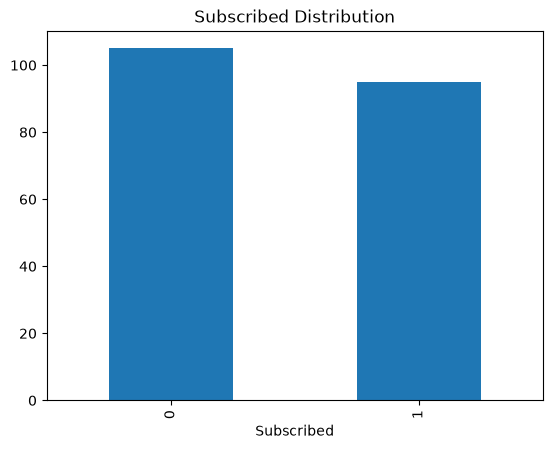

In [ ]:
df["Subscribed"].value_counts().plot(kind = "bar")      # Target variable
plt.title("Subscribed Distribution")
plt.show()

<Axes: >

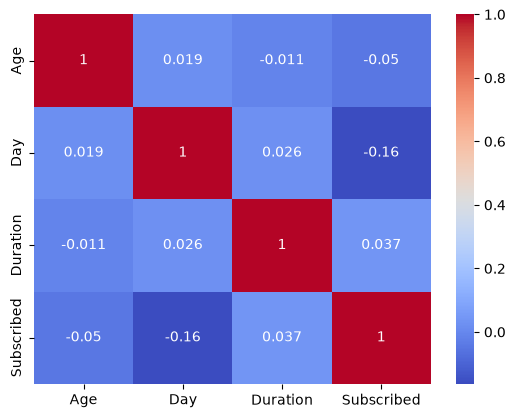

In [88]:
# Heatmap of correlation between numerical variables
correlated = df.corr(numeric_only= True)
sns.heatmap(correlated, annot=True, cmap="coolwarm") 

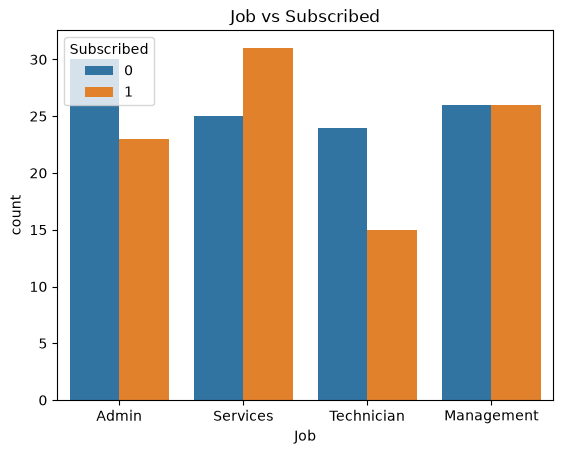

In [ ]:
# Categorical variables vs target variable
sns.countplot(x = "Job", hue = "Subscribed", data = df)
plt.title("Job vs Subscribed")
plt.show()

In [89]:

# Encode categorical columns using one-hot encoding
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True) 
print(df_encoded.columns)

Index(['Age', 'Day', 'Duration', 'Subscribed', 'Job_Management',
       'Job_Services', 'Job_Technician', 'MaritalStatus_Single',
       'Education_HighSchool', 'Education_Masters', 'HousingLoan_Yes',
       'PersonalLoan_Yes', 'Contact_Telephone'],
      dtype='str')


C:\Users\batul\AppData\Local\Temp\ipykernel_24092\2108936594.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [90]:
# Seperate input features and target variable
X = df_encoded.drop("Subscribed", axis=1)
print(X)
Y = df_encoded["Subscribed"]
print(X.shape, Y.shape)

     Age  Day  Duration  Job_Management  Job_Services  Job_Technician  \
0     55   21       521           False         False           False   
1     30   28       318           False          True           False   
2     26   24       238           False          True           False   
3     27   22       228           False         False           False   
4     29    6       182           False         False            True   
..   ...  ...       ...             ...           ...             ...   
195   37   23       142            True         False           False   
196   50   15       506           False         False            True   
197   46   25       493           False         False            True   
198   36   15       134           False         False            True   
199   49   13       520           False         False            True   

     MaritalStatus_Single  Education_HighSchool  Education_Masters  \
0                    True                 False      

In [91]:
X = pd.get_dummies(X,drop_first=True)

In [92]:
# Train-Test-Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("X_train shape :",X_train.shape)
print("X_test shape :",X_test.shape)
print("y_train shape :",y_train.shape)
print("y_test shape :",y_test.shape)

X_train shape : (160, 12)
X_test shape : (40, 12)
y_train shape : (160,)
y_test shape : (40,)


In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [98]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
y_pred = model.predict(X_test)
print("Actual :",y_test.head(10).values)
print("Predicted :",y_pred[:10])

Actual : [0 1 0 0 1 0 1 1 1 1]
Predicted : [0 1 1 0 0 1 0 1 0 0]


In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

TN, FP, FN, TP = cm.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

[[10  8]
 [16  6]]
TN: 10
FP: 8
FN: 16
TP: 6


In [102]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.4
Precision: 0.42857142857142855
Recall: 0.2727272727272727
F1 Score: 0.3333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.56      0.45        18
           1       0.43      0.27      0.33        22

    accuracy                           0.40        40
   macro avg       0.41      0.41      0.39        40
weighted avg       0.41      0.40      0.39        40



In [44]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(X.columns, "columns.pkl")



['columns.pkl']

In [63]:
print(Y.value_counts())

Subscribed
0    105
1     95
Name: count, dtype: int64
